# 1: Classifier

In this notebook, we'll train a classifier with `xgboost` to discriminate between points close to the minimum of the likelihood from those far away.

In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import sklearn.metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import json
import supertree
import tl2cgen
import treelite.frontend

_optuna = False

We load the data that we have prepared

In [2]:
df = pd.read_csv('sample_tutorial.csv')
df.describe()

,log_fa,cqL33/fa,cuR/fa,cdR/fa,clL33/fa,ceR/fa,chi2
count,41638.000000,4.163800e+04,4.163800e+04,4.163800e+04,4.163800e+04,4.163800e+04,41638.000000
mean,6.710931,1.674944e-09,5.206095e-08,7.582442e-08,-1.008463e-07,-1.244107e-08,38.311924
std,0.342768,1.248665e-07,6.214913e-07,6.077427e-07,6.573264e-07,1.339599e-07,29.898190
min,5.995225,-6.841106e-07,-2.875298e-06,-2.889838e-06,-2.939651e-06,-1.981324e-06,12.764648
25%,6.495291,-1.040439e-07,-2.229680e-07,-1.844678e-07,-2.930539e-07,-5.537717e-08,15.528566
50%,6.801755,5.276245e-11,5.222429e-09,9.657293e-08,-5.336264e-08,2.817573e-09,17.654180
75%,6.959833,1.082072e-07,2.491484e-07,2.911214e-07,1.640868e-07,4.984933e-08,80.000000
max,7.518143,9.577512e-07,2.991289e-06,2.873215e-06,2.913317e-06,8.945756e-07,80.000000


We define a cut-off for the points whose likelihood we're going to model, or to discard (try different values)

In [3]:
cutoff = 10.0

In [4]:
X = df[['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa']]
y = df['chi2']
y_classifier = (y < np.min(y) + cutoff).astype(int)

An example of how to train a classifier using most of the options:

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y_classifier, test_size=0.2)

model_clf = xgb.XGBClassifier(
    tree_method = 'hist', # Faster tree construction algorithm
    max_depth = 6, # Maximum depth of the tree
    n_estimators = 5000, # Number of trees to train
    learning_rate = 0.1, # Step size shrinkage
    gamma = 0, # Minimum loss reduction required to make a further partition
    min_child_weight = 1, # Minimum sum of instance weight needed in a child
    subsample = 0.8, # Fraction of samples to use for each tree
    colsample_bytree = 0.8, # Fraction of features to use for each tree
    eval_metric = 'logloss', # Evaluation metric
    early_stopping_rounds = 5,
    scale_pos_weight = len(y_classifier)/np.sum(y_classifier)-1, # Handle class imbalance
    nthread = -1, # Use all available CPU cores
)

model_clf.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False
              )

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

## Choosing the right hyperparameters (optional)

In [6]:
def optuna_obj(trial):
    param = {
        'objective': 'binary:logistic',
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': 200,
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
    }
    model = xgb.XGBClassifier(**param, tree_method='hist', eval_metric='logloss', early_stopping_rounds=10, nthread=-1)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    predictions = model.predict(X_val)
    accuracy = sklearn.metrics.accuracy_score(y_val, predictions)
    return accuracy

In [7]:
if _optuna:

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(optuna_obj, n_trials=400, timeout=120, n_jobs=-1, show_progress_bar=True)

    with open('best_params_clf.json', 'w') as f:
        json.dump(study.best_params, f)

## Model training

In [8]:
with open('best_params_clf.json', 'r') as f:
    best_params = json.load(f)

best_params

{'max_depth': 8,
 'learning_rate': 0.2565863025438242,
 'gamma': 0.14676060703334623,
 'min_child_weight': 1,
 'subsample': 0.5578301177825796,
 'colsample_bytree': 0.8734375311884301,
 'scale_pos_weight': 1.082804067154226,
 'reg_alpha': 0.4416850301771061,
 'reg_lambda': 0.6388011314363972}

In [9]:
model = xgb.XGBClassifier(**best_params, tree_method='hist', eval_metric=['error', 'logloss'], early_stopping_rounds=5, nthread=-1, n_estimators=200)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8734375311884301
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

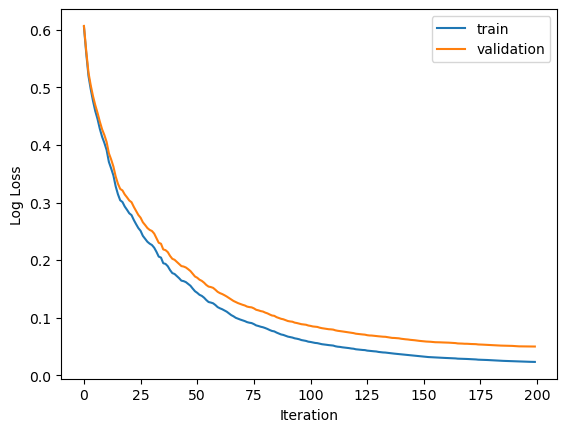

In [10]:
plt.plot(model.evals_result()['validation_0']['logloss'], label='train')
plt.plot(model.evals_result()['validation_1']['logloss'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.legend()

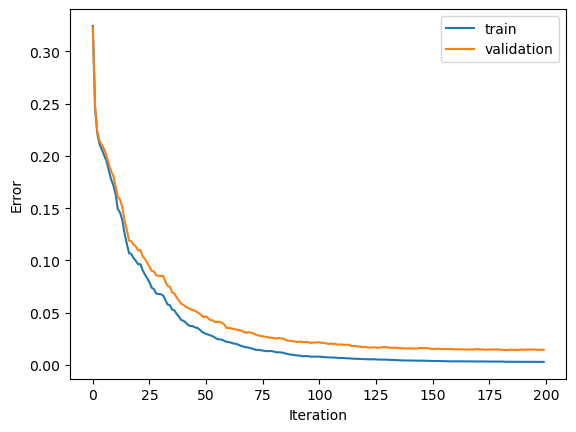

In [11]:
plt.plot(model.evals_result()['validation_0']['error'], label='train')
plt.plot(model.evals_result()['validation_1']['error'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.legend()

In [12]:
model.save_model('xgb_classifier.ubj')

In [13]:
tree_clf = treelite.frontend.from_xgboost(model.get_booster())
tl2cgen.export_lib(tree_clf, toolchain='gcc', libpath='xgb_classifier.so', params={'parallel_comp': 4})

[19:37:30] /home/conda/feedstock_root/build_artifacts/tl2cgen_1761589360479/work/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


## Tree visulization

In [14]:
st = supertree.SuperTree(model.get_booster(), X_train.values, y_train.values, feature_names = ['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'])

In [15]:
st.show_tree(0)